Question 1 a)

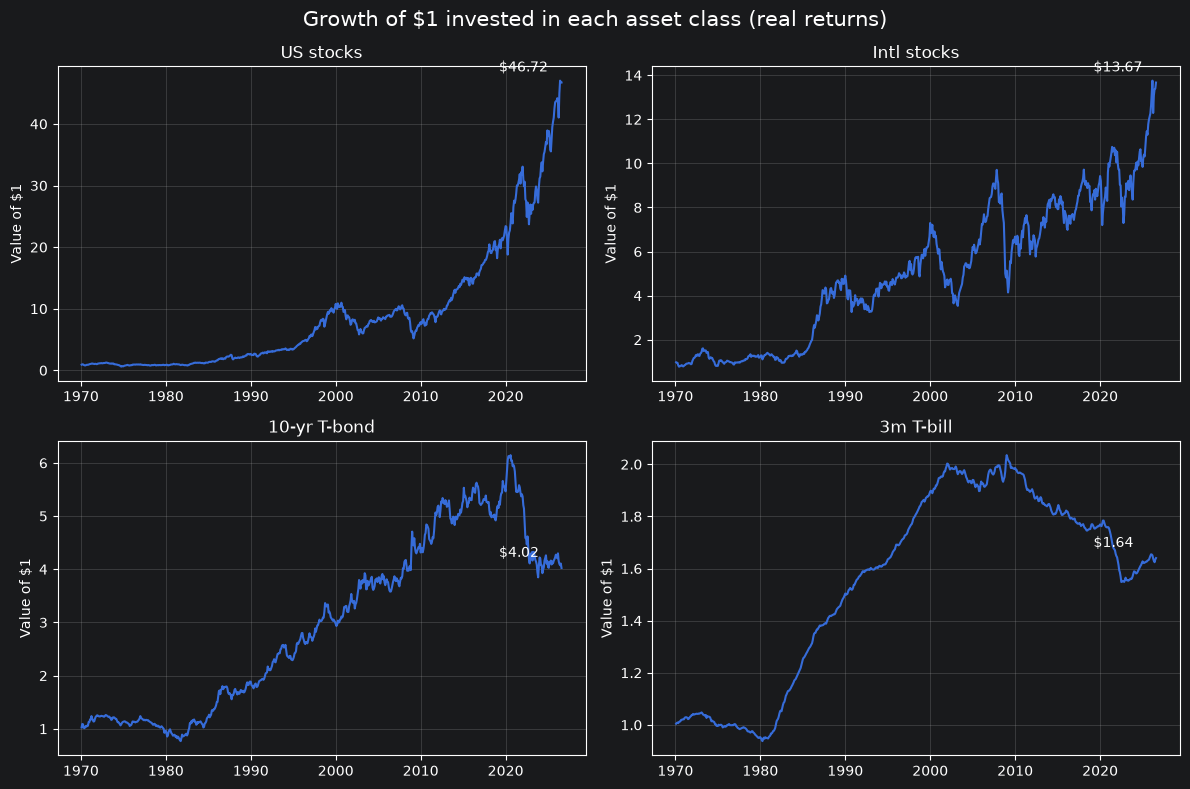

,Real mean annual return,Real annual std dev
real_us_stocks_return,8.43,16.88
real_intl_stocks_return,6.58,20.09
real_10yr_return,3.07,9.90
real_3mnth_return,0.94,2.91


In [126]:
from mqf_hw1.data import load_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics

df = load_data()
df["real_us_stocks_return"] = ((1+df["us_stocks"])/(1+df["cpi_inflation"]))-1
df["real_intl_stocks_return"] = ((1+df["intl_stocks"])/(1+df["cpi_inflation"]))-1
df["real_10yr_return"] = ((1+df["10-yr T-bond"])/(1+df["cpi_inflation"]))-1
df["real_3mnth_return"] = ((1+df["3m T-bill"])/(1+df["cpi_inflation"]))-1
df.head()

def real_mean_annual_growth(df, column, date_col="date"):
    growth = 1 + df[column]
    yearly = growth.groupby(df[date_col].dt.year).prod()
    return yearly.mean() - 1


df["date"] = pd.to_datetime(df["date"])

assets = [
    "real_us_stocks_return",
    "real_intl_stocks_return",
    "real_10yr_return",
    "real_3mnth_return",
]

def real_annual_std(df, column, date_col="date"):
    growth = 1 + df[column]
    yearly = growth.groupby(df[date_col].dt.year).prod()
    return (yearly - 1).std()

df_full = df[df["date"].dt.year < 2026]   # I am dropping it because

mean_results = {a: real_mean_annual_growth(df_full, a) for a in assets}
std_results = {a: real_annual_std(df_full, a) for a in assets}

summary = pd.DataFrame({
    "Real mean annual return": pd.Series(mean_results),
    "Real annual std dev": pd.Series(std_results),
})

assets = [
    "real_us_stocks_return",
    "real_intl_stocks_return",
    "real_10yr_return",
    "real_3mnth_return",
]
labels = ["US stocks", "Intl stocks", "10-yr T-bond", "3m T-bill"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col, label in zip(axes.flat, assets, labels):
    growth = (1 + df[col]).cumprod()          # value of $1 over time
    ax.plot(df["date"], growth)
    ax.set_title(label)
    ax.set_ylabel("Value of $1")
    ax.grid(True, alpha=0.3)
    ax.annotate(f"${growth.iloc[-1]:.2f}",
                xy=(df["date"].iloc[-1], growth.iloc[-1]),
                xytext=(-45, 8), textcoords="offset points")

fig.suptitle("Growth of $1 invested in each asset class (real returns)", fontsize=15)
fig.tight_layout()
fig.savefig("growth_of_1_dollar.png", dpi=200)
plt.show()


(summary * 100).round(2)

##took me 4hrs to write this code:( .
# A  short paragraph of interpretation:  As expected US equities significantly outperformed Fixed Income. Bills are a textbook definition of a risk free asset so the minimal returns hide behind minimal risk. 10yr Treasuries are also underperforming stocks given the absence of capital gains and the nature of high inflationary environment post Covid-19. We can see that US equities doubled since 2020 vs Both FI indexes in the red for the same period: tremendous underperformance. Intl Stocks have also underperformed the US stocks.


Question 1 b)

In [127]:
print(f"US stocks real R vs Intl stocks real R: {df['real_us_stocks_return'].corr(df['real_intl_stocks_return']):.4f}")
print(f"US stocks real R vs 10yr real R: {df['real_us_stocks_return'].corr(df['real_10yr_return']):.4f}")

US stocks real R vs Intl stocks real R: 0.6870
US stocks real R vs 10yr real R: 0.1587


Question 1 c)

In [128]:
vr_assets = {
    "Bonds (10-yr T-bond)": "real_10yr_return",
    "International stocks": "real_intl_stocks_return",
}

horizons = {"5-year": 60, "10-year": 120}

def variance_ratio(returns, k, base=1):
    log_r = np.log(1 + returns)
    var_k = log_r.rolling(k).sum().dropna().var()
    var_base = log_r.rolling(base).sum().dropna().var()
    return var_k / ((k / base) * var_base)

vr_table = pd.DataFrame({
    name: {h: variance_ratio(df[col], k) for h, k in horizons.items()}
    for name, col in vr_assets.items()
})

vr_table.round(2)

#No, both variances fall with longer lookback horizon. Although, Intl Stocks fall is sharper. Still, the findings of the Research Paper were not replicated here.

,Bonds (10-yr T-bond),International stocks
5-year,1.58,0.99
10-year,1.48,0.64


Question 1 d)

In [129]:
df["date"] = pd.to_datetime(df["date"])
d = df[df["date"].dt.year < 2026]

t1_assets = {
    "Bonds": "real_10yr_return",
    "International stocks": "real_intl_stocks_return",
}

log_infl = np.log(1 + d["cpi_inflation"])
log_dom = np.log(1 + d["real_us_stocks_return"])

def variance_ratio(returns, k, base=12):
    log_r = np.log(1 + returns)
    var_k = log_r.rolling(k).sum().dropna().var()
    var_b = log_r.rolling(base).sum().dropna().var()
    return var_k / ((k / base) * var_b)

def corr_at(log_a, log_b, k):
    """Correlation of overlapping k-month log-return sums."""
    return log_a.rolling(k).sum().corr(log_b.rolling(k).sum())

A = "Panel A: Annualized real returns"
B = "Panel B: Variance ratios"
C = "Panel C: Log real return correlations"

rows = {}
for name, col in t1_assets.items():
    r = d[col]
    log_r = np.log(1 + r)
    yearly = (1 + r).groupby(d["date"].dt.year).prod() - 1
    rows[name] = {
        (A, "Mean (%)"): yearly.mean() * 100,
        (A, "Standard deviation (%)"): yearly.std() * 100,
        (B, "VR(5)"): variance_ratio(r, 60),
        (B, "VR(10)"): variance_ratio(r, 120),
        (C, "With domestic stocks (monthly)"): corr_at(log_r, log_dom, 1),
        (C, "With domestic stocks (10-year blocks)"): corr_at(log_r, log_dom, 120),
        (C, "With inflation (monthly)"): corr_at(log_r, log_infl, 1),
        (C, "With inflation (10-year blocks)"): corr_at(log_r, log_infl, 120),
    }

table1 = pd.DataFrame(rows)
table1.index.names = ["Panel", "Measure"]

table1.round(2)

###Short Paragraph of Interpretation. Intl Stock and Bonds both seem to be uncorrelated with inflation as both have low correlation ratios with inflation. If picking one, I would say Bonds are the best hedge against inflation as they are negatively correlated with inflation in both monthly and 10 year block calculations.


Bonds  \
Panel                                 Measure                                        
Panel A: Annualized real returns      Mean (%)                                3.07   
                                      Standard deviation (%)                  9.90   
Panel B: Variance ratios              VR(5)                                   1.18   
                                      VR(10)                                  1.10   
Panel C: Log real return correlations With domestic stocks (monthly)          0.15   
                                      With domestic stocks (10-year blocks)   0.43   
                                      With inflation (monthly)               -0.28   
                                      With inflation (10-year blocks)        -0.31   

                                                                             International stocks  
Panel                                 Measure                                                      
Panel A: Annualized real returns      Mean (%)                                               6.58  
                                      Standard deviation (%)                                20.09  
Panel B: Variance ratios              VR(5)                                                  0.78  
                                      VR(10)                                                 0.50  
Panel C: Log real return correlations With domestic stocks (monthly)                         0.69  
                                      With domestic stocks (10-year blocks)                  0.48  
                                      With inflation (monthly)                              -0.13  
                                      With inflation (10-year blocks)                        0.21

Question 2

                      Growth of $1  Annualized real return (%)  \
100% T-bills                  1.64                        0.88   
100% domestic stocks         46.72                        7.03   
60/40 stocks/bonds           21.01                        5.53   
34/66 domestic/intl          23.01                        5.70   

                      Annualized volatility (%)  Sharpe ratio  
100% T-bills                               1.36           NaN  
100% domestic stocks                      15.39          0.47  
60/40 stocks/bonds                        10.25          0.50  
34/66 domestic/intl                       15.16          0.39  


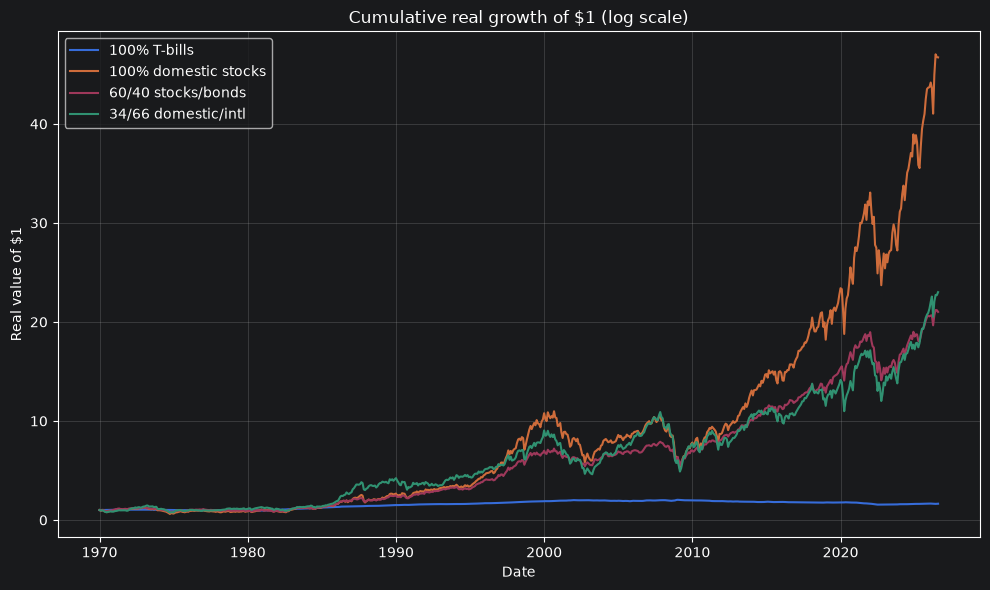

In [130]:
df["date"] = pd.to_datetime(df["date"])
p = df.set_index("date")

r_bill = p["real_3mnth_return"]
r_dom = p["real_us_stocks_return"]
r_intl = p["real_intl_stocks_return"]
r_bond = p["real_10yr_return"]


portfolios = pd.DataFrame({
    "100% T-bills": r_bill,
    "100% domestic stocks": r_dom,
    "60/40 stocks/bonds": 0.60 * r_dom + 0.40 * r_bond,
    "34/66 domestic/intl": 0.34 * r_dom + 0.66 * r_intl,
})


n_months = len(portfolios)
growth = (1 + portfolios).cumprod()
excess = portfolios.sub(r_bill, axis=0)

summary = pd.DataFrame(index=portfolios.columns)
summary["Growth of $1"] = growth.iloc[-1]
summary["Annualized real return (%)"] = (growth.iloc[-1] ** (12 / n_months) - 1) * 100
summary["Annualized volatility (%)"] = portfolios.std() * np.sqrt(12) * 100
summary["Sharpe ratio"] = (excess.mean() * 12) / (excess.std() * np.sqrt(12))

print(summary.round(2))

start = pd.DataFrame([[1.0] * 4], columns=growth.columns,
                     index=[growth.index[0] - pd.offsets.MonthEnd(1)])
wealth = pd.concat([start, growth])

fig, ax = plt.subplots(figsize=(10, 6))
for col in wealth.columns:
    ax.plot(wealth.index, wealth[col], label=col)

##ax.set_yscale("log") log axis in case needed
ax.set_title("Cumulative real growth of $1")
ax.set_xlabel("Date")
ax.set_ylabel("Real value of $1")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

The results we got here mostly agree with Anarkulova et al. First, US stocks have a clear overperformance versus any other asset type discussed here, so the optimal portfolio, similarly to Anarkulova et al. will exclude bonds and be heavy on US equity. 1$ in US stocks grew to over $46 dwarfing both short term and long term treasury returns. Also, we duplicated the Annual return domestic equities to a pip, 7.03% exactly.